In [5]:
import os

os.makedirs('dataset/apple', exist_ok=True)
os.makedirs('dataset/mango', exist_ok=True)

print("Folders created!")
print("Now add 200 apple images in dataset/apple folder")
print("And 200 mango images in dataset/mango folder")

Folders created!
Now add 200 apple images in dataset/apple folder
And 200 mango images in dataset/mango folder


In [6]:
pip install kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import subprocess
subprocess.run(['pip', 'install', 'opendatasets'])

CompletedProcess(args=['pip', 'install', 'opendatasets'], returncode=0)

In [8]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition")

Skipping, found downloaded files in ".\fruit-and-vegetable-image-recognition" (use force=True to force download)


In [9]:
import os
print(os.listdir('fruit-and-vegetable-image-recognition'))

['test', 'train', 'validation']


In [10]:
print(os.listdir('fruit-and-vegetable-image-recognition/train'))

['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [11]:
print("Apple images:", len(os.listdir('fruit-and-vegetable-image-recognition/train/apple')))
print("Banana images:", len(os.listdir('fruit-and-vegetable-image-recognition/train/banana')))

Apple images: 68
Banana images: 75


In [12]:
for folder in ['train', 'validation', 'test']:
    apple = len(os.listdir(f'fruit-and-vegetable-image-recognition/{folder}/apple'))
    banana = len(os.listdir(f'fruit-and-vegetable-image-recognition/{folder}/banana'))
    print(f"{folder} - Apple: {apple}, Banana: {banana}")

train - Apple: 68, Banana: 75
validation - Apple: 10, Banana: 9
test - Apple: 10, Banana: 9


In [13]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import os

IMG_SIZE = 128
categories = ['apple', 'banana']
base_path = 'fruit-and-vegetable-image-recognition/train'

images = []
labels = []

for label, category in enumerate(categories):
    folder = os.path.join(base_path, category)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
        labels.append(label)

X = np.array(images) / 255.0
y = np.array(labels)

print(f"Total images: {len(X)}")
print(f"Apple: {np.sum(y==0)}, Banana: {np.sum(y==1)}")

Total images: 143
Apple: 68, Banana: 75


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), verbose=1)

print("Training done!")

D:\Fruit Detection\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 687ms/step - accuracy: 0.4298 - loss: 1.1643 - val_accuracy: 0.4828 - val_loss: 0.7450
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 376ms/step - accuracy: 0.5702 - loss: 0.6729 - val_accuracy: 0.8966 - val_loss: 0.6454
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - accuracy: 0.7895 - loss: 0.6095 - val_accuracy: 0.4828 - val_loss: 0.6562
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 357ms/step - accuracy: 0.7544 - loss: 0.5174 - val_accuracy: 0.8966 - val_loss: 0.3176
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step - accuracy: 0.8333 - loss: 0.3857 - val_accuracy: 0.8966 - val_loss: 0.2810
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 341ms/step - accuracy: 0.8684 - loss: 0.3063 - val_accuracy: 0.8966 - val_loss: 0.2526
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 360ms/step - accuracy: 0.8947 - loss: 0.2912 - val_accuracy: 0.9310 - val_loss: 0.1996
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step - accuracy: 0.8947 - loss: 0.2203 - val_accuracy: 0.9655 - val_loss

In [15]:
import os
os.makedirs('models', exist_ok=True)
model.save('models/fruit_classifier.h5')
print("Model saved!")

Model saved!


Testing on an APPLE image:


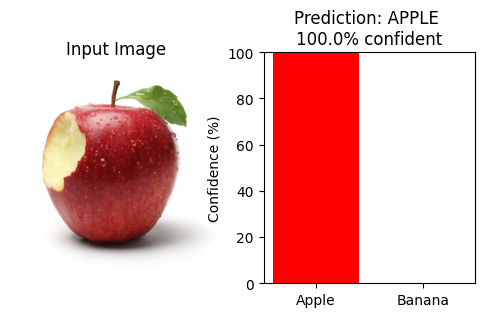


Testing on a BANANA image:


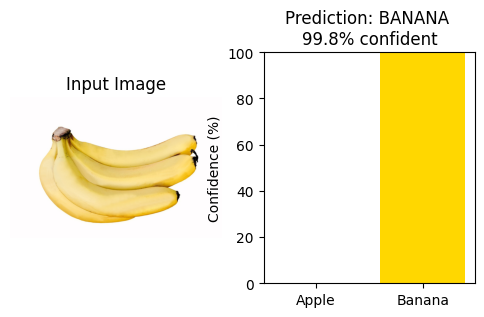

('BANANA ', array([0.0023127 , 0.99768734], dtype=float32))

In [16]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the saved model
model = load_model('models/fruit_classifier.h5')

# Function to predict a single image
def predict_fruit(image_path):
    # Read and preprocess the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img_array = np.array(img) / 255.0
    img_array = img_array.reshape(1, 128, 128, 3)
    
    # Predict
    prediction = model.predict(img_array, verbose=0)
    confidence = prediction[0]
    
    if prediction[0][0] > prediction[0][1]:
        result = "APPLE "
        apple_conf = confidence[0] * 100
        banana_conf = confidence[1] * 100
    else:
        result = "BANANA "
        apple_conf = confidence[0] * 100
        banana_conf = confidence[1] * 100
    
    # Display result
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title(f"Input Image")
    plt.axis('off')
    
    plt.subplot(1,2,2)
    bars = plt.bar(['Apple', 'Banana'], [apple_conf, banana_conf], color=['red', 'gold'])
    plt.ylim(0, 100)
    plt.ylabel('Confidence (%)')
    plt.title(f'Prediction: {result}\n{max(apple_conf, banana_conf):.1f}% confident')
    plt.show()
    
    return result, confidence

# Test on a sample image from your dataset
test_apple = 'fruit-and-vegetable-image-recognition/test/apple/' + os.listdir('fruit-and-vegetable-image-recognition/test/apple')[0]
test_banana = 'fruit-and-vegetable-image-recognition/test/banana/' + os.listdir('fruit-and-vegetable-image-recognition/test/banana')[0]

print("Testing on an APPLE image:")
predict_fruit(test_apple)

print("\nTesting on a BANANA image:")
predict_fruit(test_banana)

In [42]:
def predict_my_fruit(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Could not read image. Check the file path!")
        return None
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (128, 128))
    img_array = np.array(img_resized) / 255.0
    img_array = img_array.reshape(1, 128, 128, 3)
    
    prediction = model.predict(img_array, verbose=0)
    max_confidence = max(prediction[0]) * 100
    
    if max_confidence < 99:
        result = "UNKNOWN FRUIT"
    elif prediction[0][0] > prediction[0][1]:
        result = "APPLE"
    else:
        result = "BANANA"
    
    if result != "UNKNOWN FRUIT":
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.imshow(img_rgb)
        plt.title("Your Image")
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.bar(['Apple', 'Banana'], [prediction[0][0]*100, prediction[0][1]*100], color=['red', 'gold'])
        plt.ylim(0, 100)
        plt.ylabel('Confidence (%)')
        plt.title(f'Prediction: {result}\n({max_confidence:.1f}% confident)')
        plt.show()
    else:
        plt.figure(figsize=(4,4))
        plt.imshow(img_rgb)
        plt.title("UNKNOWN FRUIT - Not Apple or Banana")
        plt.axis('off')
        plt.show()
    print(f"\nResult: {result} ({max_confidence:.1f}% confident)")
    return result
    
print("Function updated!")

Function updated!


In [31]:
import os
print(os.listdir(r"E:\\"))

['$RECYCLE.BIN', 'bye22.jpg', 'Cisco Packet Tracer 9.0.0', 'DLLs', 'Doc', 'funny1.jpg', 'hello3.jpg', 'include', 'Lib', 'libs', 'LICENSE.txt', 'NEWS.txt', 'python.exe', 'python3.dll', 'python311.dll', 'pythonw.exe', 'Scripts', 'System Volume Information', 'tcl', 'Tools', 'vcruntime140.dll', 'vcruntime140_1.dll']


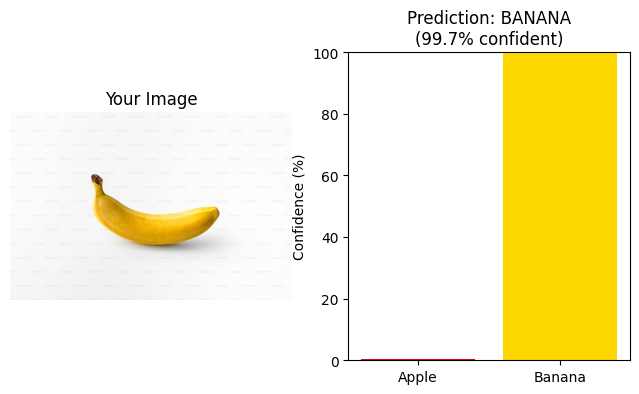


Result: BANANA (99.7% confident)


'BANANA'

In [32]:
my_image = r"E:\hello3.jpg"
predict_my_fruit(my_image)

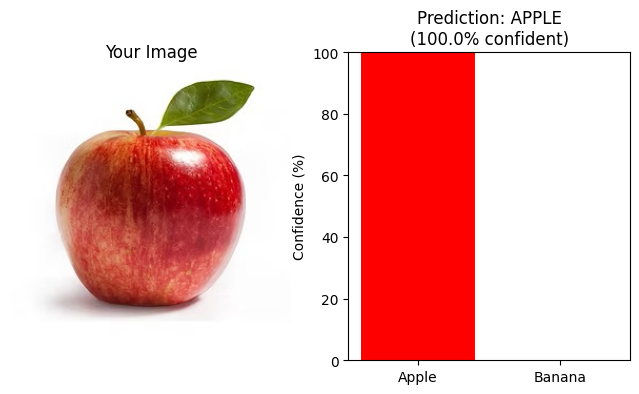


Result: APPLE (100.0% confident)


'APPLE'

In [33]:
my_image = r"E:\bye22.jpg"
predict_my_fruit(my_image)

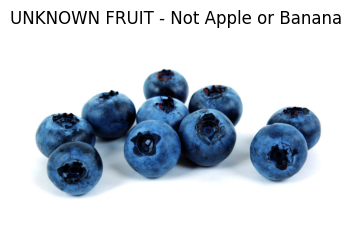


Result: UNKNOWN FRUIT (98.6% confident)


'UNKNOWN FRUIT'

In [43]:
my_image = r"E:\funny1.jpg"
predict_my_fruit(my_image)